# 02a — Batching & Formatting Tax

This notebook isolates and quantifies the predictive and operational impacts of prompt batching and compact TOON formatting using `gpt-5.4`. It compares four controlled conditions over 3 runs each to establish a statistical baseline for the 'formatting tax' and 'batching tax' on credit risk predictions.

### The 4 Conditions compared:
1. **Control (Natural Individual):** Individual API calls (1 per loan) using natural language key-value formats. (Reused from `01b_Consistency`).
2. **Tooning Only (Compact Individual):** Individual API calls (1 per loan) using the compact pipe-delimited TOON format.
3. **Batching Only (Natural Batched):** Batched API calls (all 100 in 1 call) using verbose natural language keys repeated for each loan.
4. **Both Together (Batched TOON):** Batched API calls (all 100 in 1 call) using the compact pipe-delimited TOON format.

## Setup & Config

Imports and run settings. The model is GPT-5.4, and each of the four conditions is run three times, with key-rotation so the runs can go in parallel.

In [1]:
FORCE_RERUN = False  # Set to True to re-run API calls from scratch
import sys
sys.path.insert(0, '..')

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from concurrent.futures import ThreadPoolExecutor, as_completed

from llm_utils import (
    load_llm_sample,
    run_llm_experiment,
    evaluate_predictions,
    build_system_prompt,
    build_user_prompt,
    format_loan_features,
    RESULTS_DIR,
)

# Load dotenv to ensure spare keys are in environment
load_dotenv('../.env', override=True)

API_PROVIDER = 'openai'
MODEL_NAME = 'gpt-5.4'
MODEL_LABEL = 'GPT-5.4'
N_RUNS = 3

# Setup 3-key rotation to prevent OpenAI rate limits (matching the pattern in 01b)
_key1 = os.environ.get("OPENAI_API_KEY")
_key2 = os.environ.get("OPENAI_API_KEY_2") or _key1
_key3 = os.environ.get("OPENAI_API_KEY_3") or _key1
_KEYS = {1: _key1, 2: _key2, 3: _key3}

# Flat, de-duplicated key list + worker count for the parallel run_llm_experiment calls.
API_KEYS = list(dict.fromkeys(k for k in _KEYS.values() if k))
MAX_WORKERS = max(1, len(API_KEYS) * 4)

print(f"API Provider : {API_PROVIDER}")
print(f"Model Name   : {MODEL_NAME}")
print(f"Runs per split: {N_RUNS}")
print(f"API Keys loaded: {len(set(_KEYS.values()))} unique key(s) across {N_RUNS} runs.")

API Provider : openai
Model Name   : gpt-5.4
Runs per split: 3
API Keys loaded: 3 unique key(s) across 3 runs.


In [2]:
# Force reload llm_utils from disk (preserves active variables like toon_individual_runs in memory)
import importlib
import llm_utils
importlib.reload(llm_utils)
from llm_utils import run_llm_experiment, build_user_prompt

## Load Data

This uses the same 100-loan sample as the Phase 1 notebooks, so the tax measured here lines up with those results.

In [4]:
llm_sample = load_llm_sample()
y_true = llm_sample['loan_status'].values

print(f"Sample: {len(llm_sample)} loans | "
      f"Fully Paid: {(y_true==1).sum()} | Charged Off: {(y_true==0).sum()}")

Sample: 100 loans | Fully Paid: 85 | Charged Off: 15


## Condition 2 — Tooning Only (Individual Calls + TOON format)

Each loan application is sent in a separate, individual API call (retaining max attention capacity) but formatted using the compact pipe-separated TOON format instead of verbose natural language keys. Runs are executed in parallel across 3 API keys.

In [5]:
from llm_utils import LLM_FEATURES

def individual_toon_prompt_fn(row):
    features = [c for c in LLM_FEATURES if c in row.index]
    header = "Fields: " + " | ".join(features)
    vals = []
    for f in features:
        v = row.get(f, "N/A")
        vals.append("N/A" if pd.isna(v) else str(v))
    row_str = "#0: " + " | ".join(vals)
    return f"{header}\n{row_str}"

def run_toon_individual(run_idx):
    # run_idx is 0-indexed; _KEYS is 1-indexed
    return run_llm_experiment(
        llm_sample,
        use_cache=not FORCE_RERUN,
        api_provider=API_PROVIDER,
        model_name=MODEL_NAME,
        api_keys=API_KEYS,
        max_workers=MAX_WORKERS,
        include_desc=False,
        label=f"{MODEL_LABEL} | Tooning Only | run{run_idx + 1}",
        with_logprobs=True,
        user_prompt_fn=individual_toon_prompt_fn,
        batch_size=None,
    )

print(f"Launching {N_RUNS} runs of Condition 2 in parallel across keys...")
toon_individual_runs = [None] * N_RUNS

with ThreadPoolExecutor(max_workers=N_RUNS) as pool:
    futures = {pool.submit(run_toon_individual, i): i for i in range(N_RUNS)}
    for future in as_completed(futures):
        idx = futures[future]
        toon_individual_runs[idx] = future.result()
        print(f"Tooning Only - Run {idx + 1} complete.")

print("All Condition 2 runs finished.")

SyntaxError: positional argument follows keyword argument (921782797.py, line 27)

## Condition 3 — Batching Only (1 Batched Call + Natural Language format)

All 100 loans are packaged together and processed in a single, batched API call, but we write out each loan in verbose natural language key-values. This isolates the 'batching tax' from the formatting change. Runs are executed in parallel across 3 API keys.

In [ ]:
def run_batched_natural(run_idx):
    return run_llm_experiment(
        llm_sample,
        use_cache=not FORCE_RERUN,
        api_provider=API_PROVIDER,
        model_name=MODEL_NAME,
        api_keys=API_KEYS,
        max_workers=MAX_WORKERS,
        include_desc=False,
        label=f"{MODEL_LABEL} | Batching Only | run{run_idx + 1}",
        with_logprobs=False, # Logprobs not supported in batch mode anyway
        user_prompt_fn=lambda r: build_user_prompt(r, include_desc=False),
        batch_size=0,
    )

print(f"Launching {N_RUNS} runs of Condition 3 in parallel across keys...")
batched_natural_runs = [None] * N_RUNS

with ThreadPoolExecutor(max_workers=N_RUNS) as pool:
    futures = {pool.submit(run_batched_natural, i): i for i in range(N_RUNS)}
    for future in as_completed(futures):
        idx = futures[future]
        batched_natural_runs[idx] = future.result()
        print(f"Batching Only - Run {idx + 1} complete.")

print("All Condition 3 runs finished.")

## Condition 4 — Both Together (1 Batched Call + TOON format)

All 100 loans are packaged together in a single API call and represented using the compact pipe-delimited TOON table format. Runs are executed in parallel across 3 API keys.

In [ ]:
def run_batched_toon(run_idx):
    return run_llm_experiment(
        llm_sample,
        use_cache=not FORCE_RERUN,
        api_provider=API_PROVIDER,
        model_name=MODEL_NAME,
        api_keys=API_KEYS,
        max_workers=MAX_WORKERS,
        include_desc=False,
        label=f"{MODEL_LABEL} | Batched TOON | run{run_idx + 1}",
        with_logprobs=False,
        user_prompt_fn=None, # None in batch mode defaults to the standard pipe-delimited TOON format
        batch_size=0,
    )

print(f"Launching {N_RUNS} runs of Condition 4 in parallel across keys...")
batched_toon_runs = [None] * N_RUNS

with ThreadPoolExecutor(max_workers=N_RUNS) as pool:
    futures = {pool.submit(run_batched_toon, i): i for i in range(N_RUNS)}
    for future in as_completed(futures):
        idx = futures[future]
        batched_toon_runs[idx] = future.result()
        print(f"Batched TOON - Run {idx + 1} complete.")

print("All Condition 4 runs finished.")

## Compile & Analyze Results

Gather accuracy, F1, and token cost for each condition, averaged over the three runs, with the Control row taken from 01b's no_desc runs. The differences from that Control are what we call the formatting tax and the batching tax.

In [ ]:
def get_experiment_metrics(run_results, condition_name):
    # Extract predictive metrics from runs
    accs = [r['metrics']['accuracy'] for r in run_results]
    f1s = [r['metrics']['f1_charged_off'] for r in run_results]
    recalls = [r['metrics']['recall_charged_off'] for r in run_results]
    precisions = [r['metrics']['precision_charged_off'] for r in run_results]
    
    # Load llm_calls.csv to get tokens and cost
    calls_df = pd.read_csv(f"{RESULTS_DIR}/llm_calls.csv")
    
    run_costs = []
    run_tokens_in = []
    run_tokens_out = []
    for run_i in range(1, N_RUNS + 1):
        run_label = f"{MODEL_LABEL} | {condition_name} | run{run_i}"
        sub = calls_df[calls_df['label'] == run_label]
        run_costs.append(sub['cost_usd'].sum())
        run_tokens_in.append(sub['input_tokens'].sum())
        run_tokens_out.append(sub['output_tokens'].sum())
        
    return {
        'condition': condition_name,
        'accuracy_mean': np.mean(accs),
        'accuracy_std': np.std(accs),
        'co_f1_mean': np.mean(f1s),
        'co_f1_std': np.std(f1s),
        'co_recall_mean': np.mean(recalls),
        'co_recall_std': np.std(recalls),
        'co_precision_mean': np.mean(precisions),
        'co_precision_std': np.std(precisions),
        'cost_mean': np.mean(run_costs),
        'tokens_in_mean': np.mean(run_tokens_in),
        'tokens_out_mean': np.mean(run_tokens_out),
    }

def load_baseline_metrics():
    p1b_metrics_path = f"{RESULTS_DIR}/01b_metrics.csv"
    p1b_df = pd.read_csv(p1b_metrics_path)
    baseline_runs = p1b_df[p1b_df['condition'] == 'no_desc'].copy()
    
    # Load llm_calls.csv to get tokens and cost
    calls_df = pd.read_csv(f"{RESULTS_DIR}/llm_calls.csv")
    
    run_costs = []
    run_tokens_in = []
    run_tokens_out = []
    for run_i in range(1, N_RUNS + 1):
        run_label = f"GPT-5.4 Run {run_i} (no_desc)"
        sub = calls_df[calls_df['label'] == run_label]
        run_costs.append(sub['cost_usd'].sum())
        run_tokens_in.append(sub['input_tokens'].sum())
        run_tokens_out.append(sub['output_tokens'].sum())
        
    return {
        'condition': 'Control (Natural Indiv)',
        'accuracy_mean': baseline_runs['accuracy'].mean(),
        'accuracy_std': baseline_runs['accuracy'].std(),
        'co_f1_mean': baseline_runs['f1_charged_off'].mean(),
        'co_f1_std': baseline_runs['f1_charged_off'].std(),
        'co_recall_mean': baseline_runs['recall_charged_off'].mean(),
        'co_recall_std': baseline_runs['recall_charged_off'].std(),
        'co_precision_mean': baseline_runs['precision_charged_off'].mean(),
        'co_precision_std': baseline_runs['precision_charged_off'].std(),
        'cost_mean': np.mean(run_costs),
        'tokens_in_mean': np.mean(run_tokens_in),
        'tokens_out_mean': np.mean(run_tokens_out),
    }

# Compile everything
rows = []
try:
    rows.append(load_baseline_metrics())
except Exception as e:
    print(f"Could not load baseline control from 01b: {e}")

rows.append(get_experiment_metrics(toon_individual_runs, 'Tooning Only'))
rows.append(get_experiment_metrics(batched_natural_runs, 'Batching Only'))
rows.append(get_experiment_metrics(batched_toon_runs, 'Batched TOON'))

metrics_df = pd.DataFrame(rows).set_index('condition')
print("\n--- COMPILATION OF RUNS (MEANS AND STDS) ---")
cols = ['accuracy_mean', 'accuracy_std', 'co_f1_mean', 'co_f1_std', 'co_recall_mean', 'co_recall_std', 'cost_mean']
print(metrics_df[cols].to_string(float_format='{:.4f}'.format))

# Save to results directory
metrics_df.to_csv(f"{RESULTS_DIR}/02a_tax_metrics.csv")
print(f"\nSaved metrics summary to: {RESULTS_DIR}/02a_tax_metrics.csv")


--- COMPILATION OF RUNS (MEANS AND STDS) ---
                         accuracy_mean  accuracy_std  co_f1_mean  co_f1_std  co_recall_mean  co_recall_std  cost_mean
condition                                                                                                            
Control (Natural Indiv)         0.8067        0.0231      0.3270     0.0522          0.3111         0.0385     0.2491
Tooning Only                    0.7833        0.0047      0.3159     0.0048          0.3333         0.0000     0.2046
Batching Only                   0.6200        0.0082      0.3449     0.0049          0.6667         0.0000     0.1733
Batched TOON                    0.6200        0.0163      0.2371     0.0345          0.4000         0.0943     0.0984

Saved metrics summary to: /Users/alemz/Projects/Github/Sabadell_Capstone/data/results/llm/02a_tax_metrics.csv


## Visualization of the Taxes

Plot the predictive impact (accuracy and F1) next to the operational impact (cost per run), which makes a condition that is cheaper but worse easy to spot.

/var/folders/3j/vsgbs8q90jq8blkg2_rmc8dh0000gn/T/ipykernel_36902/1704671900.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(conditions, rotation=15, ha='right')


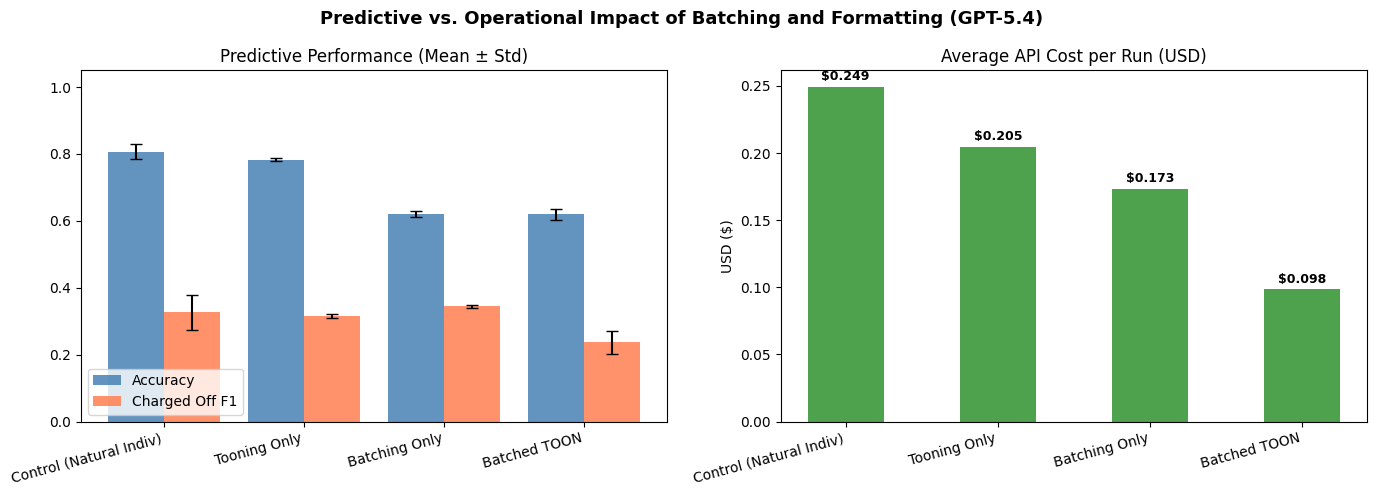

Saved comparison plot to: /Users/alemz/Projects/Github/Sabadell_Capstone/data/results/llm/02a_tax_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Predictive vs. Operational Impact of Batching and Formatting (GPT-5.4)", fontsize=13, fontweight='bold')

conditions = metrics_df.index.tolist()
x = np.arange(len(conditions))

# Left plot: F1 and Accuracy
axes[0].bar(x - 0.2, metrics_df['accuracy_mean'], 0.4, yerr=metrics_df['accuracy_std'], label='Accuracy', color='steelblue', alpha=0.85, capsize=4)
axes[0].bar(x + 0.2, metrics_df['co_f1_mean'], 0.4, yerr=metrics_df['co_f1_std'], label='Charged Off F1', color='coral', alpha=0.85, capsize=4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions, rotation=15, ha='right')
axes[0].set_title("Predictive Performance (Mean ± Std)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower left')

# Right plot: Cost
axes[1].bar(conditions, metrics_df['cost_mean'], color='forestgreen', alpha=0.8, width=0.5)
axes[1].set_title("Average API Cost per Run (USD)")
axes[1].set_ylabel("USD ($)")
for i, v in enumerate(metrics_df['cost_mean']):
    axes[1].text(i, v + (metrics_df['cost_mean'].max()*0.02), f"${v:.3f}", ha='center', fontweight='bold', fontsize=9)
axes[1].set_xticklabels(conditions, rotation=15, ha='right')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/02a_tax_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved comparison plot to: {RESULTS_DIR}/02a_tax_comparison.png")